In [1]:
import pandas as pd
import csv
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [40]:
data = np.load('C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\003_mutation_deep_learning_mp_10000.npz', allow_pickle=True)
data['simulacoes_com_erro']

array([], dtype=object)

In [42]:
def load_data():
    #['tree_data', 'rescale_factor', 'internal_nodes_order', 'ancestor', 'mutation_positions', 'number_of_mutantes', 
    # 'time_of_surgimento_mutacao', 'total_time_of_simulation', 'simulacoes_com_erro', 'index_order', 'tabela_parametros']
    data = np.load('C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\003_mutation_deep_learning_mp_10000.npz', allow_pickle=True)
    #simulacoes_com_erro = [59295 59562 95849]
    trees_cblv = data['tree_data']
    if data['simulacoes_com_erro'].size > 0:
        trees_cblv = np.delete(trees_cblv, data['simulacoes_com_erro'], axis=0)


    #correção temporária, apagar isso depois:
    trees_cblv = np.vstack(trees_cblv).astype(np.float32)


    #R_0_1, infectuos time and a taxa relativa 
    # Retornando a segunda coluna (coluna referente ao R_nought)
    # e em segunda transformando a lista em um np.array

    tabela_de_parametros = data['tabela_parametros']
    if data['simulacoes_com_erro'].size > 0:
        tabela_de_parametros = np.delete(tabela_de_parametros, data['simulacoes_com_erro'], axis=0)

    R_nought1 = np.array([sublist[0] for sublist in tabela_de_parametros])
    R_nought2 = np.array([sublist[1] for sublist in tabela_de_parametros])
    infectious_time = np.array([sublist[8] for sublist in tabela_de_parametros])
    proportion_tr11_tr22 = np.array([sublist[10] for sublist in tabela_de_parametros])
    
    rescale_factors = np.array(data['rescale_factor'], dtype=np.float64)
    if data['simulacoes_com_erro'].size > 0:
        rescale_factors = np.delete(rescale_factors, data['simulacoes_com_erro'])   

    infectious_time_div_reascale = np.round(infectious_time / rescale_factors, 3)

    vectorized = np.column_stack((R_nought1, infectious_time_div_reascale, proportion_tr11_tr22))

    return trees_cblv, vectorized, rescale_factors


In [43]:
X, y, rescale_factors = load_data()
test_size = 1000
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=False
)

In [44]:
modelo_derivado = tf.keras.models.load_model("neural_networks_dot_keras\\model_4-05_normalizado.keras")

In [45]:
print(X.dtype)
print(y.dtype)

float32
float64


In [46]:
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
pred = modelo_derivado.predict(X_test)
pred = scaler.inverse_transform(pred)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [47]:
y_test

array([[1.021, 2.535, 1.656],
       [2.222, 4.731, 1.682],
       [1.454, 2.777, 2.459],
       ...,
       [2.267, 3.541, 2.485],
       [3.842, 6.999, 2.048],
       [3.656, 4.794, 2.149]])

In [48]:
pred[:, 1] *= rescale_factors[-test_size:]
y_test[:, 1] *= rescale_factors[-test_size:]


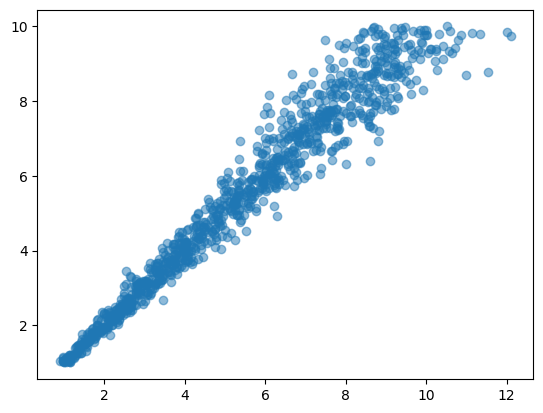

In [49]:
plt.scatter(pred[:, 1], y_test[:, 1], alpha=0.5)
plt.show()

In [50]:
pred[-10:,:]

array([[2.9811954, 1.9898165, 2.020137 ],
       [3.4904613, 8.665644 , 2.594563 ],
       [4.431352 , 1.0947595, 2.0401978],
       [4.3209963, 3.3404622, 2.4495633],
       [3.3617153, 9.507846 , 2.6980078],
       [2.4244602, 8.8387165, 1.9527656],
       [3.1235068, 2.1859648, 2.006239 ],
       [2.1846514, 9.799834 , 1.9658897],
       [4.085985 , 6.3134365, 1.9128991],
       [3.9286559, 1.2538846, 1.9913056]], dtype=float32)

In [51]:
erros = np.abs(pred - y_test)
mae_por_variavel = np.mean(erros, axis=0)

print("MAE R0:", mae_por_variavel[0])
print("MAE infectious_time:", mae_por_variavel[1])
print("MAE proportion:", mae_por_variavel[2])

MAE R0: 0.32085618161201457
MAE infectious_time: 0.3786131268985389
MAE proportion: 0.2830472345571517


In [52]:
erro_relativo = np.mean(np.abs((pred - y_test) / y_test), axis=0)

print("MAPE R0:", erro_relativo[0])
print("MAPE time:", erro_relativo[1])
print("MAPE proportion:", erro_relativo[2])

MAPE R0: 0.11982733231834646
MAPE time: 0.06679437889574105
MAPE proportion: 0.13028669599010498


In [13]:
from sklearn.metrics import r2_score

r2_col1 = r2_score(y_test[:, 0], pred[:, 0])
r2_col2 = r2_score(y_test[:, 1], pred[:, 1])
r2_col3 = r2_score(y_test[:, 2], pred[:, 2])

print("R-squared R0:", r2_col1)
print("R-squared tempo:", r2_col2)
print("R-squared proportion:", r2_col3)

R-squared R0: 0.840210064122175
R-squared tempo: 0.9560142504382745
R-squared proportion: 0.33507492831214225


In [ ]:
#PROBLEMAS DE SEGMENTAÇÃO DE IMAGENS 
#e conferir a estrtura das redes
#
#colocar a tempo de surgimento da mutação na ultima entrada CBLV e passar pela rede neural para ver se ajuda no treinamento

#escrever como modifiquei o simulador
#teste de sensibilidade
#normalziação dos dados

#13/05
# conferir como uma subarvore é representada na CBLV, ver se é um intervalo conexo
# tentar implementar o RCNN

#20/05
# implementar o RCNN
# passar o indice da raiz mutante pra rede neura pra ver se aprende
# tentar o mapa inverso
# implementar o intervalo pra adicionar na RCNN